In [1]:
import torch
import numpy as np
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from torchvision.models import vgg16_bn, VGG16_BN_Weights, resnet50, ResNet50_Weights
from torch.nn.functional import one_hot
from torchvision.ops import roi_pool, nms
import matplotlib.patches as patches


from torchvision import transforms

from cvat_sdk import make_client
from cvat_sdk.pytorch import ProjectVisionDataset


from utils import RLETransform
from models import Spine, ClsTrainer, RgsTrainer, SgmTrainer

In [2]:
import torch
import torch.nn as nn
import torchvision.transforms.functional as F
import math

    
class AugTransform(nn.Module):
    def __init__(self):
        super(AugTransform, self).__init__()

    def forward(self, img: torch.Tensor, labels: list, bboxes: list, masks: list):
        angle = torch.randint(-180, 180, (1,)).item()
        masks_rotated = []
        bboxes_rotated = []
        aug_labels = []

        img_rotated = F.rotate(img, angle, expand=True)
        img_rotated = F.center_crop(img_rotated, [640,640])
        
        for mask, bbox, label in zip(masks, bboxes, labels):
            ext_mask = torch.zeros((img.shape[1], img.shape[2]), dtype=torch.uint8)

            ext_mask[int(bbox[0]):int(bbox[2]+1), int(bbox[1]):int(bbox[3]+1)] = mask[0].int()
            ext_mask = torch.unsqueeze(ext_mask, dim=0)
            ext_mask = F.rotate(ext_mask, angle, expand=True)
            ext_mask = F.center_crop(ext_mask, [640,640])

            inds = ext_mask.nonzero()
            # иногда при обрезании может полностью срезаться какая-то маска, такую маску надо полностью проигнорировать
            # проверенно, что нет таких картинок в которых из-за этого оъектов вообще не окажется
            if inds.shape[0] == 0:
                continue
                
            y1 = torch.min(inds[:,1]).item()
            x1 = torch.min(inds[:,2]).item()
            y2 = torch.max(inds[:,1]).item()
            x2 = torch.max(inds[:,2]).item()

            # коробка может срезаться и не полностью, но если она выродится в "линию", то она тоже не нужна
            if y2-y1 <= 1 or x2-x1 <= 1:
                continue

            bboxes_rotated.append([y1, x1, y2, x2])
            masks_rotated.append(torch.unsqueeze(ext_mask[0, y1:y2, x1:x2], dim=0))
            aug_labels.append(label)

        return img_rotated, aug_labels, bboxes_rotated, masks_rotated


In [3]:
class AugmentedDataset:
    def __init__(self, dataset, augmentor):
        self.dataset = dataset 
        self.augmentor = augmentor
        self.len = len(dataset)

    def __getitem__(self, ind):
        img, (labels, bboxes, masks) = self.dataset[ind]
        aug_img, aug_labels, aug_bboxes, aug_masks = self.augmentor(img, labels, bboxes, masks)
        return aug_img, (aug_labels, aug_bboxes, aug_masks)

    def __len__(self):
        return self.len

## создаем датасет из загруженных с CVAT данных

In [4]:
class_dict = {
    1: 'Apple',
    2: 'Hurma',
    3: 'Orange',
    4: 'Pear',
    5: 'Kiwi',
    6: 'Tangerine'
}

# log into the CVAT server
with make_client(host="http://10.162.1.50:8080", credentials=('admin', 'qaedwsrf123')) as client:
    # get the dataset comprising all tasks for the Validation subset of project 12345
    dataset = ProjectVisionDataset(client, project_id=2,
                                  transform = transforms.ToTensor(),
                                  target_transform = RLETransform())

train_size = len(dataset) - 50
val_size = 50

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])


print(f'train size: {len(train_dataset)}; val size: {len(val_dataset)}')

Server version '2.30.1' is not compatible with SDK version '2.32.0'. Some SDK functions may not work properly with this server. You can continue using this SDK, or you can try to update with 'pip install cvat-sdk'.


train size: 601; val size: 50


In [5]:
problems = []
for i in range(len(dataset)):
    try:
        _,_ = dataset[i]
    except:
        problems.append(i)

problems

[]

In [6]:
ROI_SHAPE = (14,14)
DETECTION_CLASSES = 6
IMAGE_SHAPE = (640, 640)
SCALE = 32
NMS_THRESHOLD = 0.15

In [7]:
# переписать эту херь с другим порядком индексов
def get_GT_of_bbox(bbox, GT_bboxes, GT_labels, overlap=0.3):
    '''
    computing ground truth labels of given bbox in original image cordinates
    '''
    y1, x1, y2, x2 = bbox
    bbox_area = (x2 - x1) * (y2 - y1)
    if bbox_area == 0:
        return 0
    
    max_overlap = 0
    best_id = 0
    best_bbox = None
    
    for gt_bbox, label in zip(GT_bboxes, GT_labels):
        gt_y1, gt_x1, gt_y2, gt_x2 = gt_bbox
        
        # Вычисляем координаты пересечения
        inter_x1 = max(x1, gt_x1)
        inter_y1 = max(y1, gt_y1)
        inter_x2 = min(x2, gt_x2)
        inter_y2 = min(y2, gt_y2)
        
        # Вычисляем ширину и высоту пересечения
        inter_width = inter_x2 - inter_x1
        inter_height = inter_y2 - inter_y1
        
        # Если пересечение существует
        if inter_width > 0 and inter_height > 0:
            inter_area = inter_width * inter_height
            overlap_ratio = inter_area / bbox_area
            
            # Проверяем условие на минимальное пересечение и сравниваем с текущим максимальным пересечением
            if overlap_ratio >= overlap and inter_area > max_overlap:
                max_overlap = inter_area
                best_id = label
                best_bbox = gt_bbox

    
    return best_id, best_bbox

# класс всей mask r-cnn целиком
class Segment:
    def __init__(
        self,
        device,
        spine,
        
        classifier,
        regressor, 
        segmentator,
    ):
        self.device = device
        
        self.spine = spine
        self.spine.eval()
        
        self.classifier = classifier
        self.regressor = regressor
        self.segmentator = segmentator

        self.skip = {'classifier': False,
                    'regressor': False,
                    'segmentator': False}


    # лучше это переоформить как связку хребта и классификатора
    def spine_to_classifier(self, batch, mode='train', targets=None, boxes=None):
        # getting image features
        with torch.no_grad():
            sample = self.spine(batch.to(self.device))

        # getting classifier labels for each achor_box of single image in batch
        BATCH = 0
            
        ancors_batch = sample[BATCH, :, boxes[0,0]:boxes[0,2], boxes[0,1]:boxes[0,3]]
        ancors_batch = torch.unsqueeze(ancors_batch, dim=0)
        
        for i in range(1, len(boxes)):
            batch_element = sample[BATCH, :, boxes[i,0]:boxes[i,2], boxes[i,1]:boxes[i,3]]
            batch_element = torch.unsqueeze(batch_element, dim=0)
            
            ancors_batch = torch.cat((ancors_batch, batch_element), dim=0)


        # отправляем полученный батч в классификатор
        if mode == 'train':
            self.classifier.train_step(ancors_batch.detach(), targets.float().to(self.device))

            return sample, ancors_batch, None
        elif mode == 'query':
            classifierHead_response = self.classifier.query(ancors_batch.detach())

            # от classifierHead_response ищем лосс и делаем step при обучении
            # сделать метод для сопоставления места ancor_box и места bbox из GT
        
            # verdict = torch.argmax(classifierHead_response, dim=1).cpu()
            score, verdict = torch.max(classifierHead_response, dim=1)
            
            # признаки изображения и класс каждого маленького бокса общей нумерации
            return sample, ancors_batch, (score, verdict)
        elif mode == 'eval':
            self.classifier.eval_step(ancors_batch.detach(), targets.float().to(self.device))

            return sample, ancors_batch, None
        elif mode == 'skip':
            return sample, ancors_batch, None


    def foreground_to_regressor(self, boxes_features, positions, mode='train', targets=None):
        if mode == 'train':
            self.regressor.train_step((boxes_features.detach(), positions), targets)

            return None
        elif mode == 'query':
            transforms = self.regressor.query((boxes_features, positions))

            return transforms
        elif mode == 'eval':
            self.regressor.eval_step((boxes_features.detach(), positions), targets)

            return None

    def roi_to_segmentator(self, roi_features, mode='train', targets=None):
        if mode == 'train':
            self.segmentator.train_step(roi_features.detach(), targets)

            return None
        elif mode == 'query':
            masks = self.segmentator.query(roi_features)

            return masks
        elif mode == 'eval':
            self.segmentator.eval_step(roi_features.detach(), targets)

            return None
        

    # здесь будем определять GT для всех голов и вызывать их в нужном режиме
    def train_step(self, image, targets, mode='train'):
        GT_labels, GT_bboxes, GT_masks = targets
        image = torch.unsqueeze(image, dim=0).to(self.device)

        # создаем тензор с координатами боксов на тензоре признаков sample
        sample_boxes = [torch.unsqueeze(el, dim=0) for el in self.anchor_boxes(sample_size = (IMAGE_SHAPE[0]//SCALE, IMAGE_SHAPE[1]//SCALE))]
        sample_boxes = torch.cat(sample_boxes, dim=0)

        # собираем истинные метки классов всех ancor_box и, если они не фон, их истинные размеры
        ancor_boxes_GT_labels = []
        bboxes_GT = []
        small_bboxes_ind = []

        # переходим в большие координаты
        image_boxes = sample_boxes*SCALE
        for ind, image_box in enumerate(image_boxes):
            GT_label, GT_bbox = get_GT_of_bbox(image_box, GT_bboxes, GT_labels)
            
            ancor_boxes_GT_labels.append(GT_label)
            if GT_label != 0:
                bboxes_GT.append(GT_bbox)
                small_bboxes_ind.append(ind)

        # истинные значения боксов в больших координатах
        bboxes_GT = torch.tensor(bboxes_GT).to(self.device)
        #идексы коробок которые имеют истинную метку не фона
        small_bboxes_ind = torch.tensor(small_bboxes_ind)
       
        # истинные метки классов всех ancor_box
        ancor_boxes_GT_labels = torch.tensor(ancor_boxes_GT_labels)
        ancor_boxes_GT_labels = one_hot(ancor_boxes_GT_labels, num_classes=DETECTION_CLASSES+1)

        if self.skip["classifier"]:
            cls_mode = 'skip'
        else:
            cls_mode = mode
        # positions в координатах признаков
        sample, boxes_features, verdict = self.spine_to_classifier(image, 
                                                                   mode=cls_mode, 
                                                                   targets=ancor_boxes_GT_labels, 
                                                                   boxes=sample_boxes)



        # Классификатор отработал. Ищем истинные трансформации для не фоновых боксов
        # Примечание: регрессор обучается на истинных данных, а не на даных основанных 
        # на работе классификатора. При рабочем режиме модели boxes_features и positions
        # пойдут в регрессор на прямую
    
        if not self.skip["regressor"]:
            regressor_targets = self.get_GT_transforms(sample_boxes[small_bboxes_ind].to(self.device), bboxes_GT)
    
            transforms = self.foreground_to_regressor(boxes_features[small_bboxes_ind], 
                                                      sample_boxes[small_bboxes_ind].to(self.device),
                                                      mode=mode,
                                                      targets=regressor_targets)

        # transforms будем применять к sample_boxes[verdict!=0] при рабочем режиме
        # при обучении воспользуемся regressor_targets примененными к sample_boxes[small_bboxes_ind]

        if not self.skip["segmentator"]:
            GT_bboxes = torch.tensor(GT_bboxes).to(self.device)
            ROI_boxes = torch.cat((torch.zeros((GT_bboxes.shape[0], 1)).to(self.device), GT_bboxes), dim=-1)
            # в сегментатор на обучении подаем GT боксы. Выделяем данные для него по уточненным коробкам
            ROI_samples = roi_pool(sample, boxes=ROI_boxes, output_size=ROI_SHAPE, spatial_scale=1.0/SCALE)
    
            GT_masks = self.get_GT_masks(GT_masks, GT_labels)
            sampled_masks = self.roi_to_segmentator(ROI_samples, 
                                                    mode=mode,
                                                    targets=GT_masks.to(self.device))

        
        
    # вызываем train_step для всех элементов датасета
    def train(self, train_dataset, val_dataset, epoches=1):            
        for epo in tqdm(range(epoches)):
            for i in torch.randperm(len(train_dataset)):
                image, targets = train_dataset[i]
                self.train_step(image, targets, mode='train')

            for image, targets in val_dataset:
                self.train_step(image, targets, mode='eval')

            if not self.skip["classifier"]:
                self.classifier.epoch_end()
            if not self.skip["regressor"]:
                self.regressor.epoch_end()
            if not self.skip["segmentator"]:
                self.segmentator.epoch_end()


    # вызываем все головы в рабочем режиме
    def __call__(self, image):
        mode = 'query'
        image = torch.unsqueeze(image, dim=0).to(self.device)

        # создаем тензор с координатами боксов на тензоре признаков sample
        sample_boxes = [torch.unsqueeze(el, dim=0) for el in self.anchor_boxes(sample_size = (IMAGE_SHAPE[0]//SCALE, IMAGE_SHAPE[1]//SCALE))]
        sample_boxes = torch.cat(sample_boxes, dim=0)

        # positions в координатах признаков
        sample, boxes_features, verdict = self.spine_to_classifier(image, 
                                                                   mode=mode,
                                                                   boxes=sample_boxes)
        
        score, verdict = verdict
        score = score[verdict!=0]
        
        boxes_features = boxes_features[verdict!=0]
        sample_boxes = sample_boxes[verdict!=0].to(self.device)
        transforms = self.foreground_to_regressor(boxes_features, 
                                                  sample_boxes,
                                                  mode=mode)

        sample_boxes = self.apply_transforms(sample_boxes, transforms)
        # найдены откоректированные коробки, их метки классов и уровень доверия к меткам.
        # можно отбросить лишнее при помощи non-max suppression
        verdict = verdict[verdict!=0]
        
        keep_ind = nms(sample_boxes, score, iou_threshold=NMS_THRESHOLD)
        sample_boxes = sample_boxes[keep_ind]
        verdict = verdict[keep_ind]
        score = score[keep_ind]

        ROI_boxes = torch.cat((torch.zeros((sample_boxes.shape[0], 1)).to(self.device), sample_boxes), dim=-1)
        # в сегментатор на обучении подаем GT боксы. Выделяем данные для него по уточненным коробкам
        ROI_samples = roi_pool(sample, boxes=ROI_boxes, output_size=ROI_SHAPE, spatial_scale=1.0/SCALE)


        sampled_masks = self.roi_to_segmentator(ROI_samples, 
                                                mode=mode)

        return (score, verdict), sample_boxes, sampled_masks


        

        

    @staticmethod
    def anchor_boxes(sample_size = (40,40), box_size = (2,2), stride = 2):
        '''
        returns all boxes by parameters y_top, x_left, y_bot, x_right
        box tensor will be: sample[BATCH, :, box[0]:box[2], box[1]:box[3]]
        '''
        for y in range(0, sample_size[0], stride):
            for x in range(0, sample_size[1], stride):
                yield torch.tensor([y,x,y+box_size[0],x+box_size[1]])

    # ancor_box в маленьких координатах, bboxes_GT в больших
    def get_GT_transforms(self, ancor_box, bboxes_GT):
        '''
        transform cordinates of sample
        '''
        ancor_box_GT = bboxes_GT/SCALE
        
        transforms_GT = torch.zeros_like(ancor_box_GT)
        
        # t_x = (G_x - P_x)/P_w
        transforms_GT[:, 0] = (ancor_box_GT[:,0]-ancor_box[:,0])/ancor_box[:,2]
    
        # t_y = (G_y - P_y)/P_h
        transforms_GT[:, 1] = (ancor_box_GT[:,1]-ancor_box[:,1])/ancor_box[:,3]
        
        # t_w = ln(G_w/P_w)
        transforms_GT[:, 2] = torch.log(ancor_box_GT[:,2]/ancor_box[:,2])
        
        # t_h = ln(G_h/P_h)
        transforms_GT[:,3] = torch.log(ancor_box_GT[:,3]/ancor_box[:,3])
    
        return transforms_GT

    # применяем корректироваки регрессора
    def apply_transforms(self, ancor_box, transforms):
        bbox_output = torch.zeros_like(ancor_box, dtype=torch.float)
    
        # G_x = t_x*P_w + P_x
        bbox_output[:, 0] = transforms[:,0]*ancor_box[:,2] + ancor_box[:,0]
    
        # G_y = t_y*P_h + P_y
        bbox_output[:, 1] = transforms[:,1]*ancor_box[:,3] + ancor_box[:,1]
        
        # G_w = exp(t_w)*P_w
        bbox_output[:, 2] = torch.exp(transforms[:,2])*ancor_box[:,2]
        
        # G_h = exp(t_h)*P_h
        bbox_output[:, 3] = torch.exp(transforms[:,3])*ancor_box[:,3]
    
        return bbox_output

    # фона здесь уже нет, метки классов сдвигаются на 1. Нулевая маска отображает 1 класс
    def get_GT_masks(self, raw_masks, GT_labels):
        resize = transforms.Resize((56,56))
        GT_masks = torch.zeros((len(raw_masks), DETECTION_CLASSES, 56, 56)).float()

        for ind, raw_mask in enumerate(raw_masks):
            GT_masks[ind, GT_labels[ind]-1, :, :] = resize(raw_mask)

        return GT_masks

    def to(self, device):
        self.device = device
        self.spine.to(device)
        self.classifier.to(device)
        self.regressor.to(device)
        self.segmentator.to(device)
                

In [8]:
def DICE(pred, target):
    smooth = 0.1
    bs = pred.size(0)
    m1 = pred.view(bs, -1)  # Flatten
    m2 = target.view(bs, -1)  # Flatten
    intersection = (m1 * m2).sum()

    return (2.0 * intersection + smooth) / (m1.sum() + m2.sum() + smooth)

def segmentation_loss(output, target):
    BCE = torch.nn.BCELoss()
    return BCE(output, target) - 0.4*torch.log(DICE(output, target))

In [9]:
class ResNet50Processor(nn.Module):
    def __init__(self):
        super(ResNet50Processor, self).__init__()
        

        layers_list = []
        for layer in resnet50(weights=ResNet50_Weights.DEFAULT).children():
            layers_list.append(layer)

        self.conv = nn.Sequential(*layers_list[:-2])

        for param in self.conv.parameters():
            param.requires_grad = False

        
    
    def forward(self, x):
        return self.conv(x)

In [10]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'

print(device)

# spine = Spine(vgg16_bn(weights = VGG16_BN_Weights.IMAGENET1K_V1)).to(device)
spine = ResNet50Processor().to(device)


class_weights = torch.tensor([0.05, 1.5, 1.0, 1.0, 1.0, 1.0, 1.0]).to(device)
classifier_criterion = torch.nn.BCELoss(weight = class_weights)

classifier = ClsTrainer(lr = 0.0005, gamma = 0.95, criterion = classifier_criterion).to(device)


regressor_criterion = nn.SmoothL1Loss()
regressor = RgsTrainer(lr = 0.008, gamma = 0.8, criterion = regressor_criterion).to(device)


segmentator = SgmTrainer(lr = 0.01, gamma = 0.8, criterion = segmentation_loss, in_channels=2048).to(device)

cuda:0


In [11]:
args = {
    'device': device,
    'spine': spine,
    'classifier': classifier,
    'regressor': regressor,
    'segmentator': segmentator
}

RCNN = Segment(**args)

In [12]:
# задействуем аугментацию датасета
augmentor = AugTransform()
train_dataset = AugmentedDataset(train_dataset, augmentor)

In [13]:
# классификатор очень быстро переобучается, учим его только 5 эпох
# остальные цифры подберем позже
RCNN.train(train_dataset, val_dataset, epoches=3)
RCNN.skip["classifier"] = True
RCNN.skip["segmentator"] = True
RCNN.train(train_dataset, val_dataset, epoches=10)

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

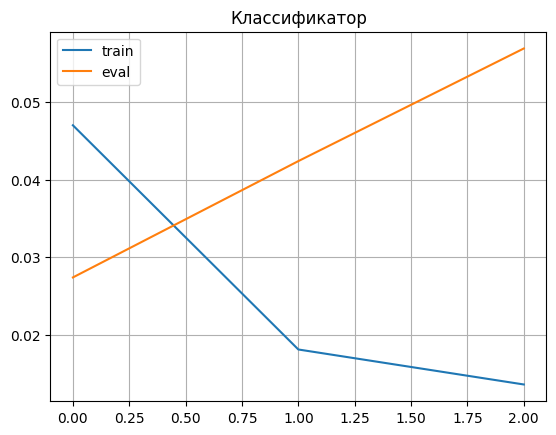

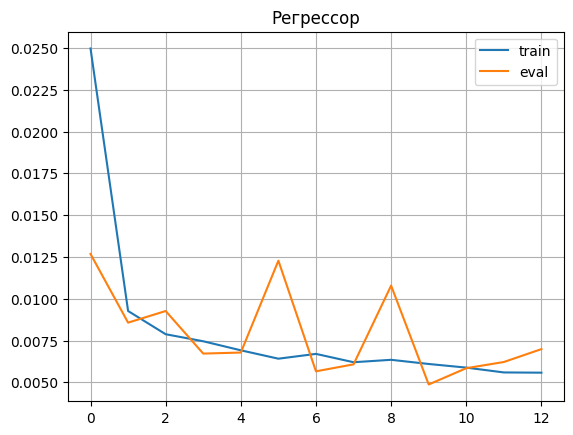

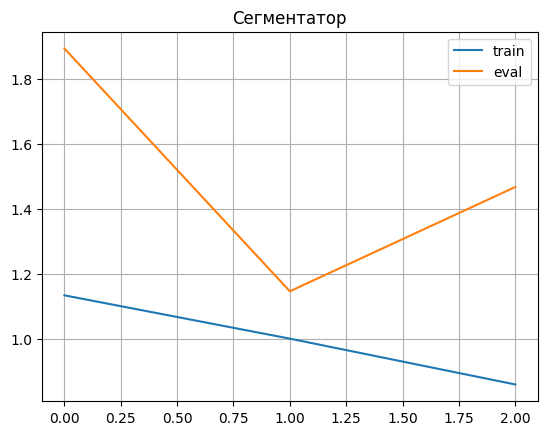

In [14]:
def show_losses(RCNN):
    plt.figure(1)
    plt.plot(RCNN.classifier.train_losses, label='train')
    plt.plot(RCNN.classifier.val_losses, label='eval')
    plt.title("Классификатор")
    plt.legend()
    plt.grid(True)
    
    plt.figure(2)
    plt.plot(RCNN.regressor.train_losses, label='train')
    plt.plot(RCNN.regressor.val_losses, label='eval')
    plt.title("Регрессор")
    plt.legend()
    plt.grid(True)
    
    plt.figure(3)
    plt.plot(RCNN.segmentator.train_losses, label='train')
    plt.plot(RCNN.segmentator.val_losses, label='eval')
    plt.title("Сегментатор")
    plt.legend()
    plt.grid(True)

show_losses(RCNN)

In [15]:
RCNN.to('cpu')

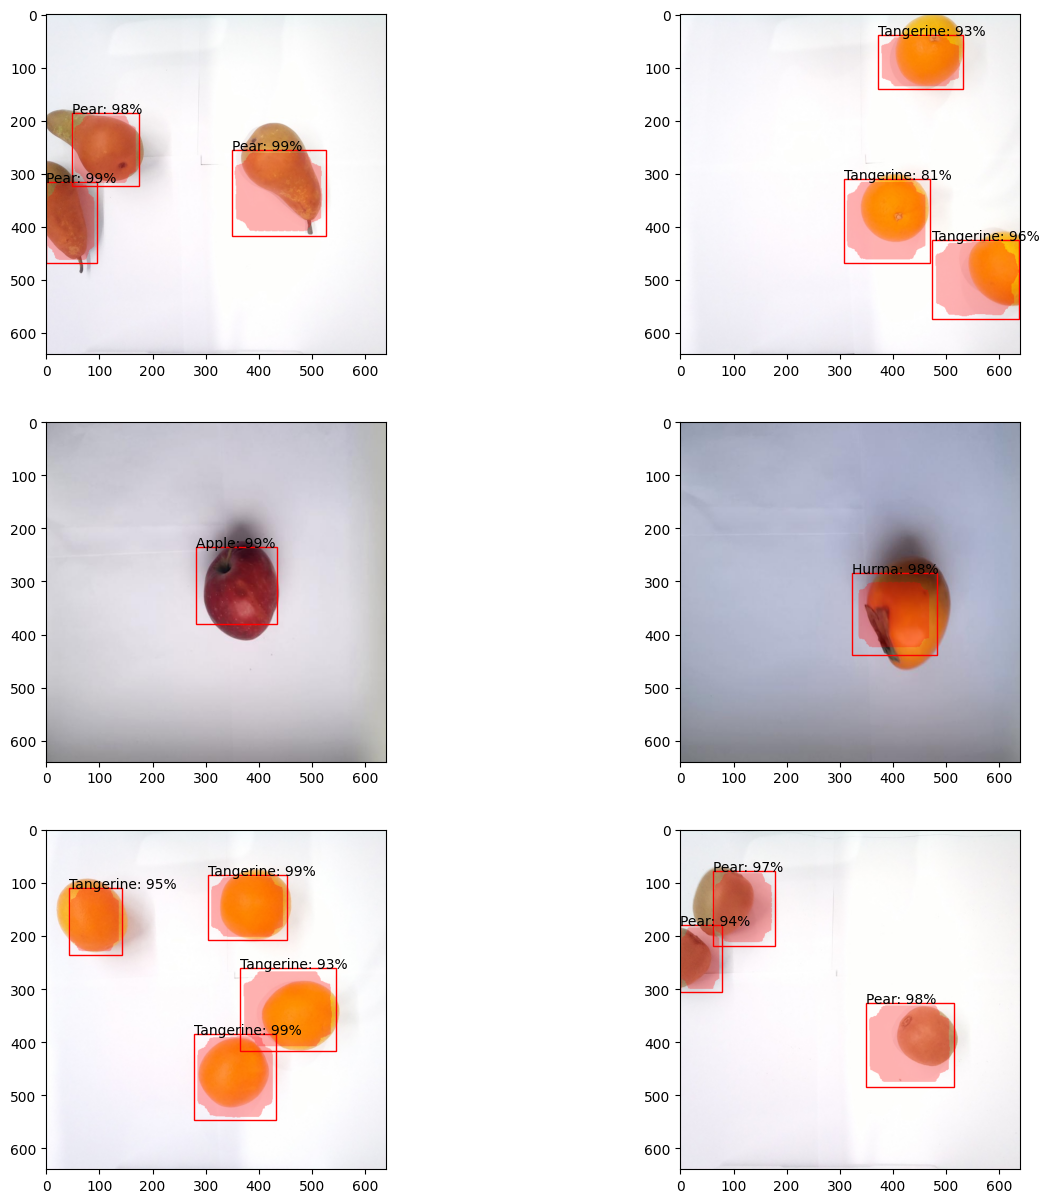

In [20]:
fig, axes = plt.subplots(3, 2, sharex=False, sharey=False, figsize=(15,15))

ind = 12
for y_axes in axes:
    for ax in y_axes:
        image = torch.permute(val_dataset[ind][0], (1,2,0))
        (scores, verdict), sample_boxes, sampled_masks = RCNN(val_dataset[ind][0])
        ind += 1
    
        raw_masks = sampled_masks[torch.arange(sampled_masks.size(0)),verdict-1, :,:]
        sample_boxes[sample_boxes<0] = 0
        sample_boxes[sample_boxes>639/SCALE] = 639/SCALE - 0.01
        
        
        rects = []
        alpha = 0.3
        for score, label, bbox, mask in zip(scores.cpu(), (verdict-1).cpu(), (sample_boxes*SCALE).int().cpu(), raw_masks.cpu()):
            try:
                resize = transforms.Resize((int(bbox[2])-int(bbox[0]), (int(bbox[3])-int(bbox[1]))))
                scaled_mask = resize(torch.unsqueeze(mask, dim=0))[0]
                real_mask = torch.zeros_like(scaled_mask)
                real_mask[scaled_mask>0.1] = 1
                
            
                appled_mask = torch.zeros((640,640))
        
        
                appled_mask[bbox[0]:bbox[2], bbox[1]:bbox[3]] = real_mask
        
        
                image[appled_mask==1] = (1.0-alpha)*image[appled_mask==1] + alpha*torch.tensor([1.0, 0.0, 0.0])
        
                ax.text(bbox[1], bbox[0], f'{class_dict[label.item()+1]}: {int(100*score)}%')
                ax.add_patch(patches.Rectangle((bbox[1], bbox[0]), bbox[3]-bbox[1], bbox[2]-bbox[0], linewidth=1, edgecolor='r', facecolor='none'))
            except:
                print(bbox)
                
        ax.imshow(image)



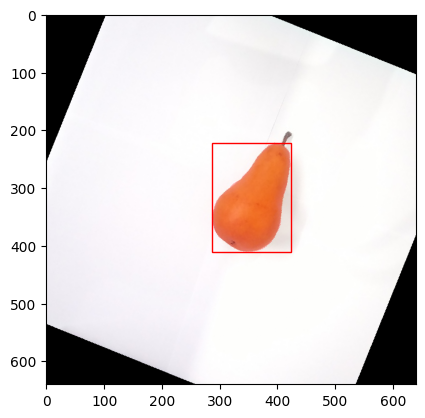

In [35]:
image_ind = 14
alpha = 0.3

image, (labels, bboxes, masks) = train_dataset[image_ind]
image = torch.permute(image, (1,2,0))


rects = []
for bbox, mask in zip(bboxes, masks):
    rects.append(patches.Rectangle((bbox[1], bbox[0]), bbox[3]-bbox[1], bbox[2]-bbox[0], linewidth=1, edgecolor='r', facecolor='none'))

    appled_mask = torch.zeros((image.shape[0],image.shape[1]))

    bbox_int = torch.tensor(bbox).int()
    
    appled_mask[bbox_int[0]:bbox_int[2], bbox_int[1]:bbox_int[3]] = mask[0]


    image[appled_mask==1] = (1-alpha)*image[appled_mask==1] + alpha*torch.tensor([1.0, 0.0, 0.0])
    
fig, ax = plt.subplots()

ax.imshow(image)
for rect in rects:
    ax.add_patch(rect)

In [18]:
# явно прослеживается проблема с семплированием боксов
# -> датасет подает боксы в порядке y,x,y,x -> регрессор работает корректно, классификатор укладывается 
# в рамки ожидаемого при условии сильного дисбаланса с фоновыми изображениями
# сегментатор совершенно не учится, стоит попробовать уменьшить размер выходной маски и увеличить размер входной
# сегментатор проснулся после уменьшения размеров маски

# нужен механизм отключения обучения разных частей модели


# отображение результатов                        работает корректно
# методы get_GT_transforms и apply_transforms    работают корректно
# метод get_GT_of_bbox                           работает корректно
